In [16]:
import pandas as pd
from pyecharts.charts import *
from pyecharts.globals import CurrentConfig,NotebookType
CurrentConfig.NOTEBOOK_TYPE=NotebookType.JUPYTER_LAB
from pyecharts import options as opts
from pyecharts.globals import ThemeType
import pymysql

In [17]:
db=pymysql.connect(
    host='localhost',
    port=3306,
    user='root',
    passwd='root',
    database='playlets'
)

In [18]:
sql='select * from history'
df=pd.read_sql(sql,db)
df

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_8176\2925924105.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(sql,db)


,id,card,update_time
0,1,"{""clipId"":""756916"",""title"":""野狗骨头"",""episode_cnt...",2026-07-24 11:41:34
1,2,"{""clipId"":""783747"",""title"":""炽夏"",""episode_cnt"":...",2026-07-24 11:42:30
2,3,"{""clipId"":""763701"",""title"":""耀眼"",""episode_cnt"":...",2026-07-24 11:42:33
3,4,"{""clipId"":""593455"",""title"":""小巷人家"",""episode_cnt...",2026-07-24 11:42:42
4,5,"{""clipId"":""851666"",""title"":""克制升温"",""episode_cnt...",2026-07-24 11:42:44
5,6,"{""clipId"":""749276"",""title"":""良陈美锦"",""episode_cnt...",2026-07-24 11:42:48
6,9,"{""clipId"":""333900"",""title"":""以家人之名"",""episode_cn...",2026-07-24 11:43:12
7,10,"{""clipId"":""857348"",""title"":""着迷"",""episode_cnt"":...",2026-07-24 11:43:38
8,11,"{""clipId"":""617394"",""title"":""五福临门"",""episode_cnt...",2026-07-24 11:43:42
9,12,"{""clipId"":""731684"",""title"":""你是迟来的欢喜"",""episode_...",2026-07-24 11:43:45


In [23]:
import re
def get_kind(x):
    res=re.search('"kind":\[(.*?)\]',x).group(1)
    return res

In [25]:
df['kind']=df['card'].apply(lambda x:get_kind(x))

In [26]:
df

,id,card,update_time,kind
0,1,"{""clipId"":""756916"",""title"":""野狗骨头"",""episode_cnt...",2026-07-24 11:41:34,"""电视剧"",""23.6亿次播放"",""电视剧热搜榜No.1"",""宋威龙"",""张婧仪"",""都市""..."
1,2,"{""clipId"":""783747"",""title"":""炽夏"",""episode_cnt"":...",2026-07-24 11:42:30,"""电视剧"",""21.1亿次播放"",""电视剧热搜榜No.8"",""包上恩"",""周柯宇"",""剧情""..."
2,3,"{""clipId"":""763701"",""title"":""耀眼"",""episode_cnt"":...",2026-07-24 11:42:33,"""电视剧"",""27.8亿次播放"",""电视剧热搜榜No.6"",""关晓彤"",""李昀锐"",""都市""..."
3,4,"{""clipId"":""593455"",""title"":""小巷人家"",""episode_cnt...",2026-07-24 11:42:42,"""电视剧"",""43.6亿次播放"",""白玉兰奖"",""电视剧热搜榜No.2"",""闫妮"",""李光洁..."
4,5,"{""clipId"":""851666"",""title"":""克制升温"",""episode_cnt...",2026-07-24 11:42:44,"""微短剧"",""2.1亿次播放"",""钟雅婷"",""陈圣亨"",""都市"",""爱情"""
5,6,"{""clipId"":""749276"",""title"":""良陈美锦"",""episode_cnt...",2026-07-24 11:42:48,"""电视剧"",""36.2亿次播放"",""任敏"",""此沙"",""爱情"",""古装"""
6,9,"{""clipId"":""333900"",""title"":""以家人之名"",""episode_cn...",2026-07-24 11:43:12,"""电视剧"",""57.9亿次播放"",""电视剧热搜榜No.9"",""谭松韵"",""宋威龙"",""家庭""..."
7,10,"{""clipId"":""857348"",""title"":""着迷"",""episode_cnt"":...",2026-07-24 11:43:38,"""微短剧"",""2.3亿次播放"",""任运杰"",""戚砚笛"",""悬疑"",""爱情"""
8,11,"{""clipId"":""617394"",""title"":""五福临门"",""episode_cnt...",2026-07-24 11:43:42,"""电视剧"",""33.1亿次播放"",""卢昱晓"",""王星越"",""爱情"",""古装"""
9,12,"{""clipId"":""731684"",""title"":""你是迟来的欢喜"",""episode_...",2026-07-24 11:43:45,"""电视剧"",""23.7亿次播放"",""魏哲鸣"",""郑合惠子"",""都市"""


In [29]:
df['date']=df['update_time'].apply(lambda x:re.search('\d+-\d+-\d{2}',str(x)).group())

In [40]:
time_list=df['date'].astype('category').cat.categories.tolist()

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

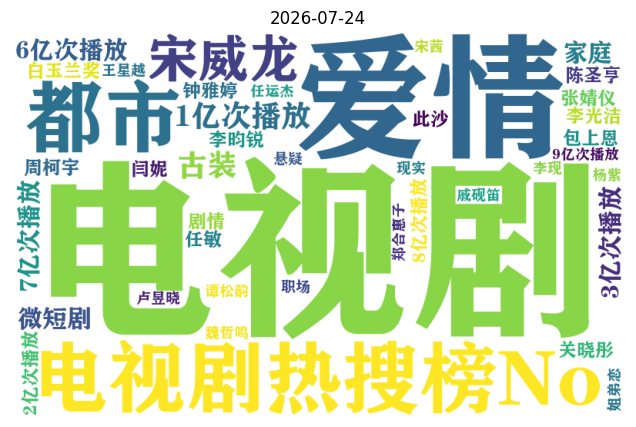

In [55]:
for time in time_list:
    day_content=df[df['date']==time]
    all_word=','.join([i for i in day_content['kind']]).replace(','," ")
    wordcloud=WordCloud(
        font_path=r'C:\Windows\Fonts\方正粗黑宋简体.ttf',
        width=800,
        height=500,
        background_color='white'
    ).generate(all_word)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(time)

In [59]:
from collections import Counter

In [74]:
tl=Timeline()
tl.add_schema()
for time in time_list:
    day_content=df[df['date']==time]
    all_word=','.join([i for i in day_content['kind']]).replace("\"",'')
    all_word_lst=all_word.split(',')
    words_count=Counter(all_word_lst)
    word_lst=[]
    count_lst=[]
    for word,count in words_count.most_common(8):
        word_lst.append(word)
        count_lst.append(count)
    bar=(Bar()
         .add_xaxis(word_lst)
         .add_yaxis('出现次数',count_lst)
    )
    tl.add(bar,time)
tl.load_javascript()
tl.render('words_count.html')

'D:\\桌面\\uniapp小程序开发\\uniapp-playlet\\backend\\words_count.html'